# Set up
**Import libraries**

In [2]:
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from knmy import knmy
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
)
from sklearn.preprocessing import RobustScaler

**Load and merge datasets**

In [3]:
df = pd.read_csv("../data/bunny.csv", dtype={'Oryctolagus cuniculus': str})
habitat = pd.read_csv("../data/habitats.csv")

# Merge habitats with bunny data with only matching decimalLatitude and decimalLongitude values
df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

In [4]:
from scipy.spatial.distance import cdist
# Stations lookup
stations_data = {
    'station': [260, 240, 280, 270, 350, 380, 290, 310, 370, 235, 275, 344, 257],
    'lat': [52.101, 52.318, 53.125, 53.202, 51.449, 50.906, 52.933, 51.501, 52.933, 52.928, 52.056, 51.962, 52.506],
    'lon': [5.177, 4.790, 6.585, 5.752, 3.596, 5.762, 4.788, 5.707, 5.444, 4.781, 5.872, 4.447, 4.604],
    'name': ['De Bilt', 'Schiphol', 'Eelde', 'Leeuwarden', 'Vlissingen', 'Maastricht', 
             'Twente', 'Eindhoven', 'Lelystad', 'De Kooy', 'Deelen', 'Rotterdam', 'Wijk aan Zee']
}
stations_df = pd.DataFrame(stations_data)

# Ensure datetime
df["eventDate"] = pd.to_datetime(df["eventDate"])

# Unique locations + nearest station
unique_locs = df[['decimalLatitude', 'decimalLongitude']].drop_duplicates().reset_index(drop=True)

loc_coords = unique_locs[['decimalLatitude', 'decimalLongitude']].values
station_coords = stations_df[['lat', 'lon']].values

distances = cdist(loc_coords, station_coords, metric='euclidean')
nearest_idx = np.argmin(distances, axis=1)

unique_locs['nearest_station'] = stations_df['station'].iloc[nearest_idx].values
unique_locs['station_name'] = stations_df['name'].iloc[nearest_idx].values


# Merge station info back
df = df.merge(unique_locs, 
              on=['decimalLatitude', 'decimalLongitude'], 
              how='left')

# Check if merge worked
print("Columns after station merge:", [col for col in df.columns if 'station' in col.lower() or 'nearest' in col.lower()])

# Download weather
start_date = df["eventDate"].min().strftime("%Y%m%d")
end_date   = df["eventDate"].max().strftime("%Y%m%d")

weather_list = []

for station_id in sorted(unique_locs['nearest_station'].unique()):
    print(f"🌧️  Downloading data for station {station_id}...")
    try:
        weather_raw = knmy.get_knmi_data(
            type="daily",
            stations=[int(station_id)],
            start=start_date,
            end=end_date
        )
        
        weather_df = pd.read_csv(StringIO(weather_raw), comment='#', skipinitialspace=True, header=None)
        
        weather_df = weather_df.rename(columns={0: "STN", 1: "YYYYMMDD", 11: "TG", 18: "SQ", 22: "RH"})
        
        weather_df["YYYYMMDD"] = weather_df["YYYYMMDD"].astype(str)
        weather_df["eventDate"] = pd.to_datetime(weather_df["YYYYMMDD"], format="%Y%m%d").dt.normalize()
        
        weather_df["temp_mean"] = pd.to_numeric(weather_df["TG"], errors="coerce") / 10
        weather_df["precip_sum"] = pd.to_numeric(weather_df["RH"], errors="coerce") / 10
        weather_df["sunshine_duration"] = pd.to_numeric(weather_df["SQ"], errors="coerce") / 10
        weather_df["station"] = station_id
        
        weather_list.append(weather_df[['eventDate', 'station', 'temp_mean', 'precip_sum', 'sunshine_duration']])
        
    except Exception as e:
        print(f"⚠️ Error for station {station_id}: {e}")

# Final merge
if weather_list:
    all_weather = pd.concat(weather_list, ignore_index=True)
    
    df = df.merge(
        all_weather, 
        left_on=['eventDate', 'nearest_station'], 
        right_on=['eventDate', 'station'], 
        how='left'
    )
    
    df = df.drop(columns=['station'], errors='ignore')   # remove duplicate
    
    print("🎉 Success! Weather merged with location-specific data.")
    print(df[['temp_mean', 'precip_sum', 'sunshine_duration']].describe())
    print("\nSample rows:")
    print(df[['eventDate', 'nearest_station', 'station_name', 'temp_mean']].head())
else:
    print("❌ No weather data was downloaded.")

Columns after station merge: ['nearest_station', 'station_name']
🌧️  Downloading data for station 235...
🌧️  Downloading data for station 240...
🌧️  Downloading data for station 257...
🌧️  Downloading data for station 260...
🌧️  Downloading data for station 270...
🌧️  Downloading data for station 275...
🌧️  Downloading data for station 280...
🌧️  Downloading data for station 290...
🌧️  Downloading data for station 310...
🌧️  Downloading data for station 344...
🌧️  Downloading data for station 350...
🌧️  Downloading data for station 370...
🌧️  Downloading data for station 380...
🎉 Success! Weather merged with location-specific data.
          temp_mean    precip_sum  sunshine_duration
count  1.255841e+07  1.255841e+07       1.255824e+07
mean   1.087049e+01  2.255315e+00       5.071856e+00
std    6.225544e+00  4.692560e+00       4.236428e+00
min   -1.380000e+01 -1.000000e-01      -1.000000e-01
25%    6.400000e+00  0.000000e+00       1.200000e+00
50%    1.080000e+01  1.000000e-01       4.

**Feature enginering**

Because of in the CRISP-DM cycle we went back and forth between data understanding and data preparation and therefore need need the data preparation part feature enigerening before data understanding we are placing it here

In [5]:
df["Oryctolagus cuniculus"] = pd.to_numeric(
    df["Oryctolagus cuniculus"],
    errors="coerce"
)

df["spotted"] = (
    df["Oryctolagus cuniculus"]
    .fillna(0)
    .gt(0)
    .astype(int)
)

df = df.sort_values(["decimalLatitude", "decimalLongitude", "eventDate"])

# Create the future spotted flag
df["is_spotted"] = (
    df.groupby(["decimalLatitude", "decimalLongitude"])["spotted"]
      .transform(lambda x: x[::-1].rolling(window=30, min_periods=1).max()[::-1].shift(-1).fillna(0).astype(int))
)

# to find time patterns
df["day_of_year"] = df["eventDate"].dt.dayofyear
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

---

# 1. Business Understanding

**Business Objective** 

* To support biodiversity monitoring by predicting whether the European rabbit (Oryctolagus cuniculus) will be observed at a specific location within a 30-day window. The final output is a one-page, non-technical poster identifying key predictors and model performance to inform wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
    * Successful delivery of a one-page poster communicating clear methodology and results.
    * Model performance meets pre-defined thresholds on unseen test data to ensure reliability for conservation action.

**Data Mining Goals**

* Build a supervised binary classification model to predict is_spotted.
* Improve class balance handling to align with ecological monitoring practices.
* Utilize environmental, spatial, and temporal features (land cover, weather, seasonality) to capture non-linear habitat patterns.

**Data Mining Success Criteria**

* Our model should achieve at least:
    * Recall (Primary): Achieve more than 60% to minimize False Negatives (missing rabbit occurrences), which are deemed more harmful than false alarms for biodiversity monitoring.
    * F1-Score (Secondary): Achieve more than 40% to ensure the model maintains a balance and does not sacrifice precision by over-predicting.
    * Evaluation: Metrics must be validated on a separate, unseen hold-out test set to ensure robustness.
    * The model should also maintain stable predictive performance across different regions and seasons.

---


# 2.1 Data understanding
**Data exploration**

In [6]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,...,nearest_station,station_name,temp_mean,precip_sum,sunshine_duration,spotted,is_spotted,day_of_year,day_sin,day_cos
12558769,3.5,52.8,2026-01-14,10.0,1011,3.0,NaN,NaN,NaN,NaN,...,380,Maastricht,8.5,4.6,0.0,1,0,14,0.238673,0.971100
12558767,3.5,52.9,2026-01-12,100.0,1011,NaN,NaN,NaN,NaN,NaN,...,380,Maastricht,5.7,6.1,0.0,0,0,12,0.205104,0.978740
12558765,3.5,53.0,2026-01-10,10.0,1011,5.0,NaN,NaN,NaN,NaN,...,380,Maastricht,-2.7,2.0,0.0,1,0,10,0.171293,0.985220
12558761,3.5,53.1,2026-01-06,99999.0,1011,8.0,NaN,NaN,NaN,NaN,...,380,Maastricht,-1.5,0.1,1.5,1,0,6,0.103102,0.994671
12558760,3.5,53.2,2026-01-05,40.0,1011,-1.0,NaN,NaN,NaN,NaN,...,380,Maastricht,-2.3,2.0,0.2,0,0,5,0.085965,0.996298


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558786 entries, 12558769 to 12558755
Data columns (total 25 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Oryctolagus cuniculus      float64       
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  nearest_station            int64         
 16  station_name               str           
 

In [8]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,...,wetland,nearest_station,temp_mean,precip_sum,sunshine_duration,spotted,is_spotted,day_of_year,day_sin,day_cos
count,1.255879e+07,1.255879e+07,12558786,1.255878e+07,1.255879e+07,1.255878e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,...,1.255876e+07,1.255879e+07,1.255841e+07,1.255841e+07,1.255824e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,2017-12-31 12:10:06.165594,8.136004e+00,2.212651e-01,7.164708e-03,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,...,2.249716e-01,2.988666e+02,1.087049e+01,2.255315e+00,5.071856e+00,5.475927e-03,9.970088e-02,1.831249e+02,1.240474e-05,6.866384e-04
min,3.500000e+00,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.350000e+02,-1.380000e+01,-1.000000e-01,-1.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,-9.999907e-01,-9.999630e-01
25%,5.170000e+01,4.900000e+00,2014-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,...,0.000000e+00,2.750000e+02,6.400000e+00,0.000000e+00,1.200000e+00,0.000000e+00,0.000000e+00,9.200000e+01,-7.055836e-01,-7.086267e-01
50%,5.220000e+01,5.650000e+00,2018-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,...,1.820000e-02,2.800000e+02,1.080000e+01,1.000000e-01,4.400000e+00,0.000000e+00,0.000000e+00,1.830000e+02,6.432491e-16,4.303538e-03
75%,5.280000e+01,6.200000e+00,2022-01-01 00:00:00,6.000000e+00,0.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,...,1.417000e-01,3.440000e+02,1.580000e+01,2.500000e+00,8.200000e+00,0.000000e+00,0.000000e+00,2.740000e+02,7.055836e-01,7.025275e-01
max,5.350000e+01,5.340000e+01,2026-01-30 00:00:00,1.000400e+05,1.637000e+03,3.730000e+02,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,...,1.422410e+01,3.800000e+02,3.120000e+01,1.316000e+02,1.570000e+01,1.000000e+00,1.000000e+00,3.660000e+02,9.999907e-01,1.000000e+00
std,6.647267e-01,8.779710e-01,NaN,6.264853e+01,2.511784e+00,2.051651e-01,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,...,7.063523e-01,3.965583e+01,6.225544e+00,4.692560e+00,4.236428e+00,7.379663e-02,2.996008e-01,1.054388e+02,7.068642e-01,7.073490e-01


In [9]:
# Basic statistical summary
print("=== Statistical Summary (Numerical Features) ===")
print(df.describe().round(4))

# Extra useful info
print("\n=== Additional Information ===")
print(f"Total number of observations: {len(df)}")
print(f"Date range: {df['eventDate'].min()} to {df['eventDate'].max()}")
print(f"Number of unique locations: {df.groupby(['decimalLatitude', 'decimalLongitude']).ngroups}")

# Missing values
print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

# Target distribution
print("\n=== Target Distribution (is_spotted) ===")
print(df['is_spotted'].value_counts(normalize=True).round(4) * 100)
print(f"Positive class (is_spotted = 1): {df['is_spotted'].mean():.2%}")

=== Statistical Summary (Numerical Features) ===
       decimalLatitude  decimalLongitude                   eventDate  \
count     1.255879e+07      1.255879e+07                    12558786   
mean      5.222990e+01      5.532900e+00  2017-12-31 12:10:06.165594   
min       3.500000e+00      3.350000e+00         2010-01-01 00:00:00   
25%       5.170000e+01      4.900000e+00         2014-01-01 00:00:00   
50%       5.220000e+01      5.650000e+00         2018-01-01 00:00:00   
75%       5.280000e+01      6.200000e+00         2022-01-01 00:00:00   
max       5.350000e+01      5.340000e+01         2026-01-30 00:00:00   
std       6.647000e-01      8.780000e-01                         NaN   

       total_observations  speciesgroup_observations  Oryctolagus cuniculus  \
count        1.255878e+07               1.255879e+07           1.255878e+07   
mean         8.136000e+00               2.213000e-01           7.200000e-03   
min          0.000000e+00               0.000000e+00          -1.

### Bunny Occurences

Data distribution of target

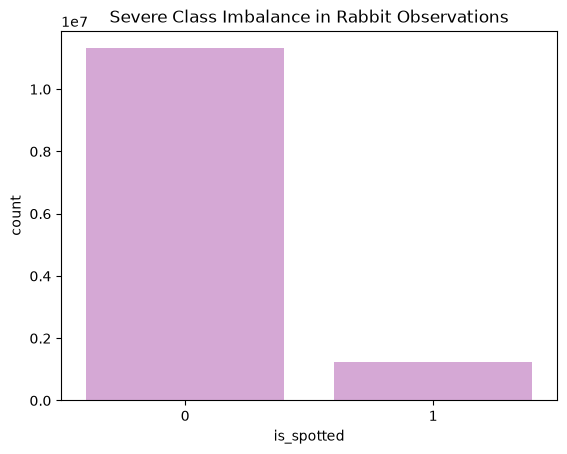

In [10]:
sns.countplot(data=df, x='is_spotted', color="plum")
plt.title('Severe Class Imbalance in Rabbit Observations')
plt.show()

### Habitats

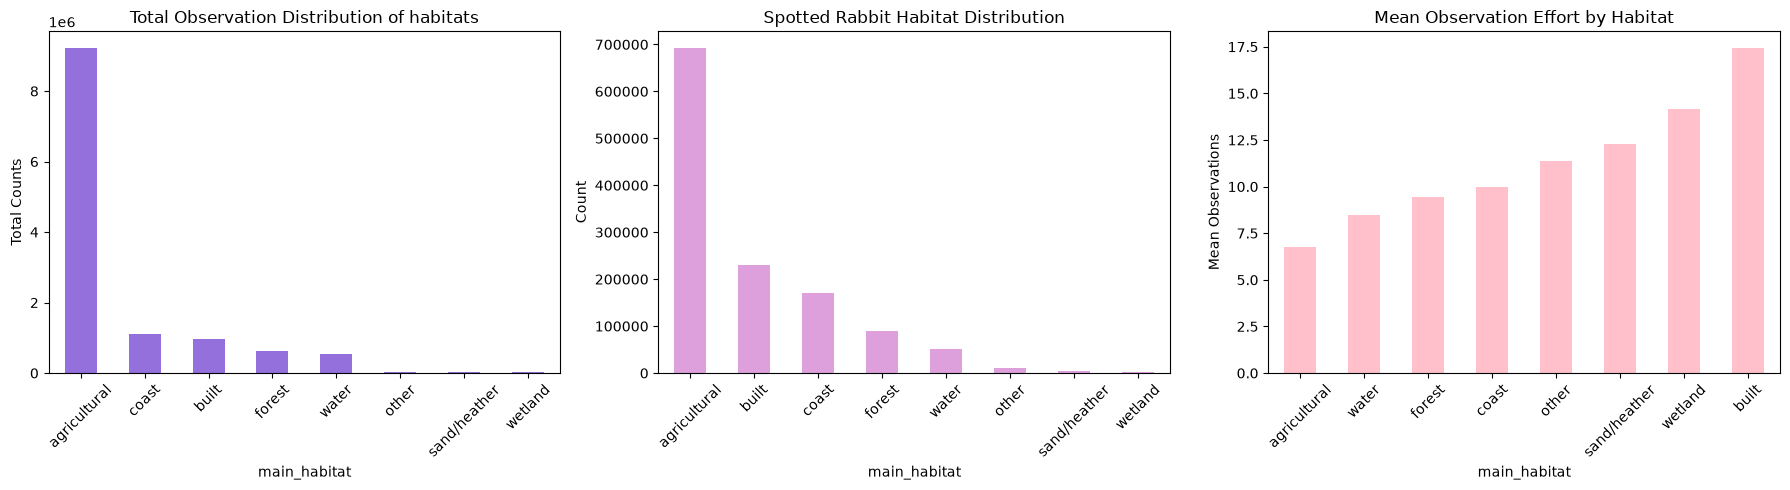

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Total Observation Distribution
df["main_habitat"].value_counts().plot(kind="bar", ax=axes[0], color="mediumpurple")
axes[0].set_title("Total Observation Distribution of habitats")
axes[0].set_ylabel("Total Counts")
axes[0].tick_params(axis='x', rotation=45)

# 2. Spotted rabbit habitat distribution
df[df["is_spotted"] == 1]["main_habitat"].value_counts().plot(kind="bar", ax=axes[1], color="plum")
axes[1].set_title("Spotted Rabbit Habitat Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# 3. Observation effort by habitat (Mean)
df.groupby("main_habitat")["total_observations"].mean().sort_values().plot(kind="bar", ax=axes[2], color="pink")
axes[2].set_title("Mean Observation Effort by Habitat")
axes[2].set_ylabel("Mean Observations")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
habitat_summary = df['main_habitat'].value_counts().reset_index()
habitat_summary.columns = ['Habitat', 'Count']
habitat_summary['Percentage'] = (habitat_summary['Count'] / habitat_summary['Count'].sum()) * 100

print(habitat_summary)

        Habitat    Count  Percentage
0  agricultural  9233520   73.522569
1         coast  1098672    8.748255
2         built   958416    7.631456
3        forest   631152    5.025593
4         water   543492    4.327594
5         other    40908    0.325733
6  sand/heather    29220    0.232666
7       wetland    23376    0.186133


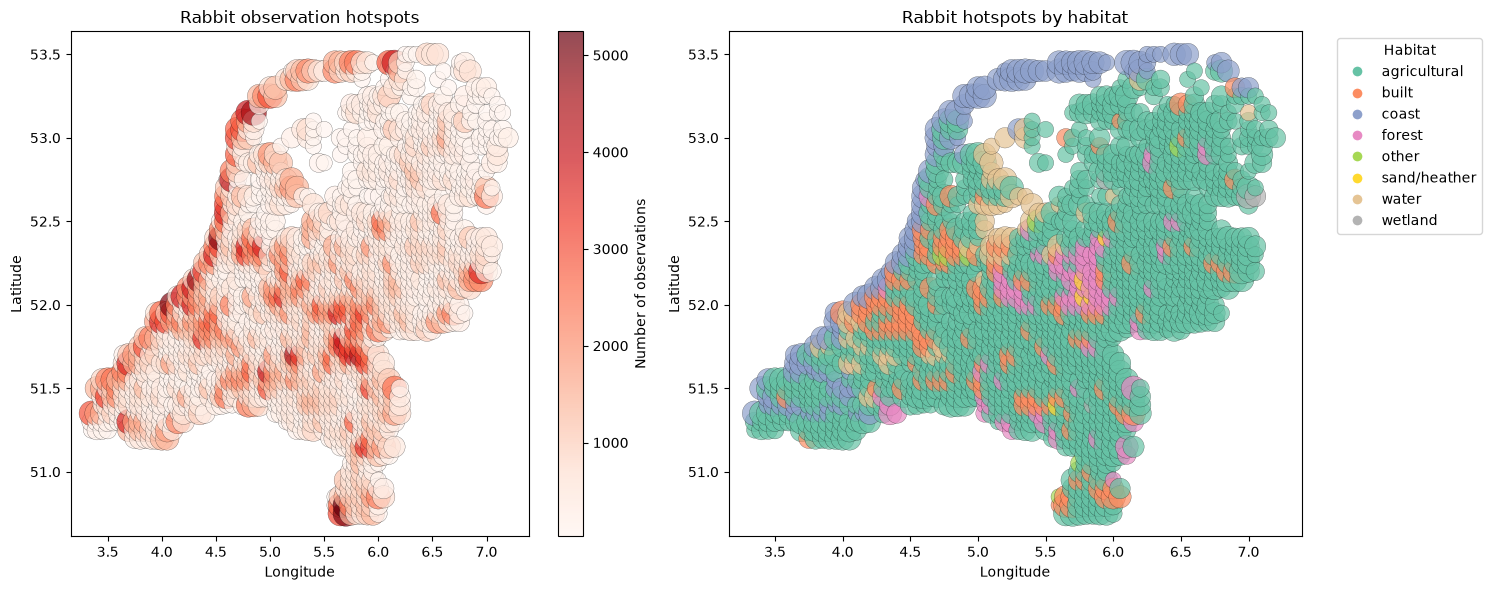

In [13]:
df_spotted = df[df["is_spotted"] == 1]

# 1. Location-only hotspot map
loc_counts_1 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude"]
).size().reset_index(name="count")

loc_counts_1["log_count"] = np.log1p(loc_counts_1["count"])

# 2. Location + habitat map
loc_counts_2 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude", "main_habitat"]
).size().reset_index(name="count")

loc_counts_2["log_count"] = np.log1p(loc_counts_2["count"])

habitats = loc_counts_2["main_habitat"].astype("category")
colors = habitats.cat.codes

# 3. Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(
    loc_counts_1["decimalLongitude"],
    loc_counts_1["decimalLatitude"],
    s=loc_counts_1["log_count"] * 40,
    c=loc_counts_1["count"],
    cmap="Reds",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[0].set_title("Rabbit observation hotspots")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("Number of observations")

sc2 = axes[1].scatter(
    loc_counts_2["decimalLongitude"],
    loc_counts_2["decimalLatitude"],
    s=loc_counts_2["log_count"] * 40,
    c=colors,
    cmap="Set2",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[1].set_title("Rabbit hotspots by habitat")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# habitat legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cm.Set2(i),
               markersize=8,
               label=cat)
    for i, cat in enumerate(habitats.cat.categories)
]

axes[1].legend(handles=handles, title="Habitat",
               bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Weather


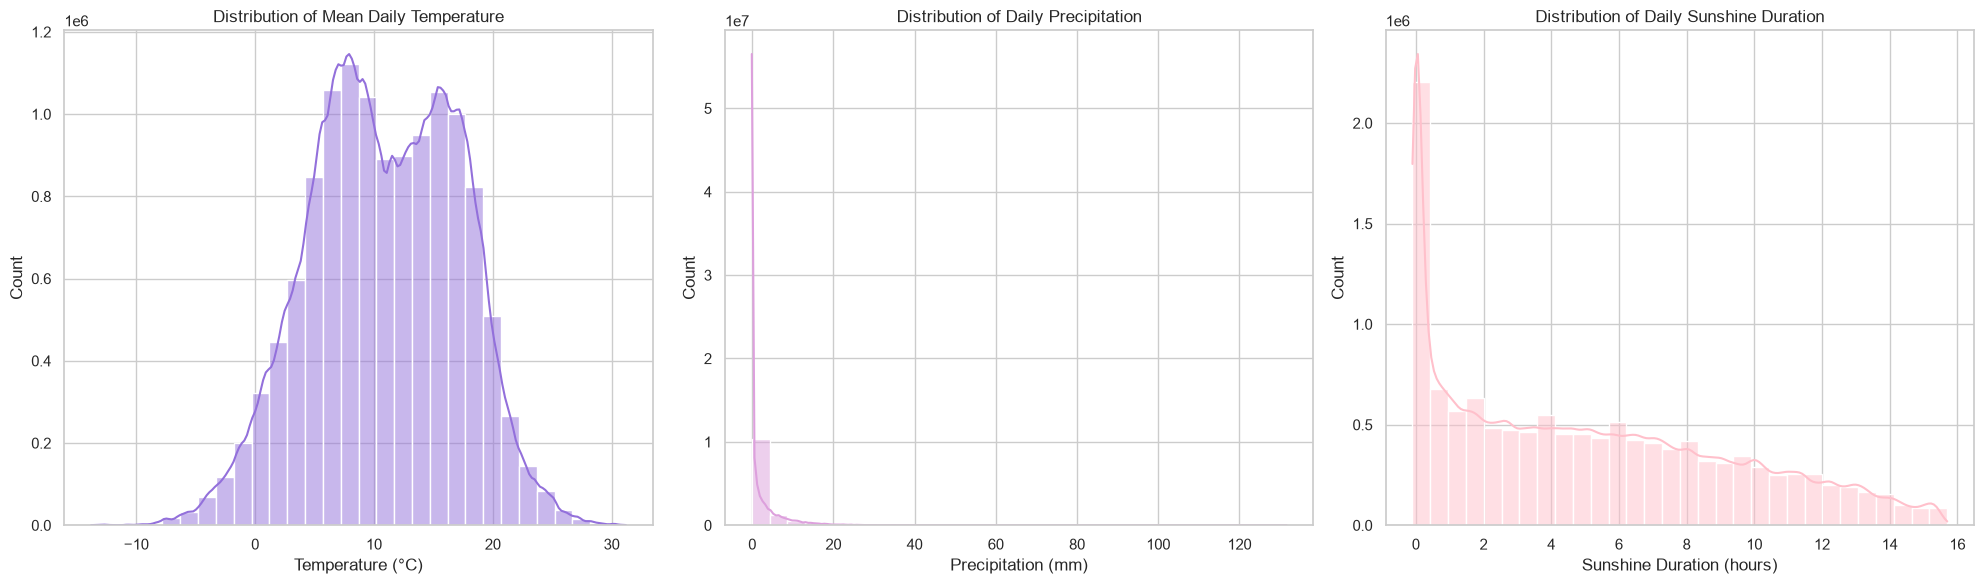

In [14]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram for Temperature
sns.histplot(df['temp_mean'], kde=True, ax=axes[0], color='mediumpurple', bins=30)
axes[0].set_title('Distribution of Mean Daily Temperature')
axes[0].set_xlabel('Temperature (°C)')

# Histogram for Precipitation
sns.histplot(df['precip_sum'], kde=True, ax=axes[1], color='plum', bins=30)
axes[1].set_title('Distribution of Daily Precipitation')
axes[1].set_xlabel('Precipitation (mm)')

# Histogram for Sunshine Duration
sns.histplot(df['sunshine_duration'], kde=True, ax=axes[2], color='pink', bins=30)
axes[2].set_title('Distribution of Daily Sunshine Duration')
axes[2].set_xlabel('Sunshine Duration (hours)')

plt.tight_layout()
plt.show()

### Seasonal

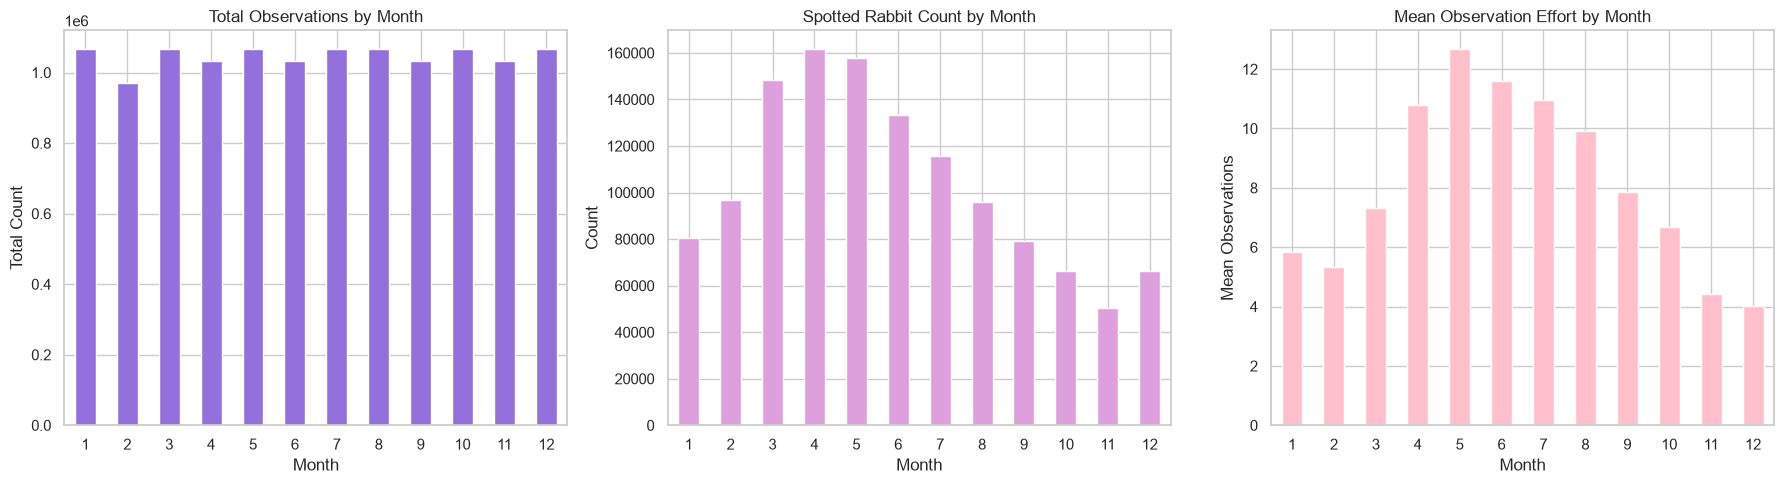

In [15]:
df["month"] = df["eventDate"].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Total Observation Distribution by Month
df["month"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="mediumpurple")
axes[0].set_title("Total Observations by Month")
axes[0].set_ylabel("Total Count")
axes[0].set_xlabel("Month")
axes[0].tick_params(axis='x', rotation=0)

# 2. Spotted rabbit distribution by Month
df[df["is_spotted"] == 1]["month"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="plum")
axes[1].set_title("Spotted Rabbit Count by Month")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis='x', rotation=0)

# 3. Mean observation effort by Month
df.groupby("month")["total_observations"].mean().sort_index().plot(kind="bar", ax=axes[2], color="pink")
axes[2].set_title("Mean Observation Effort by Month")
axes[2].set_ylabel("Mean Observations")
axes[2].set_xlabel("Month")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Correlation Heatmaps

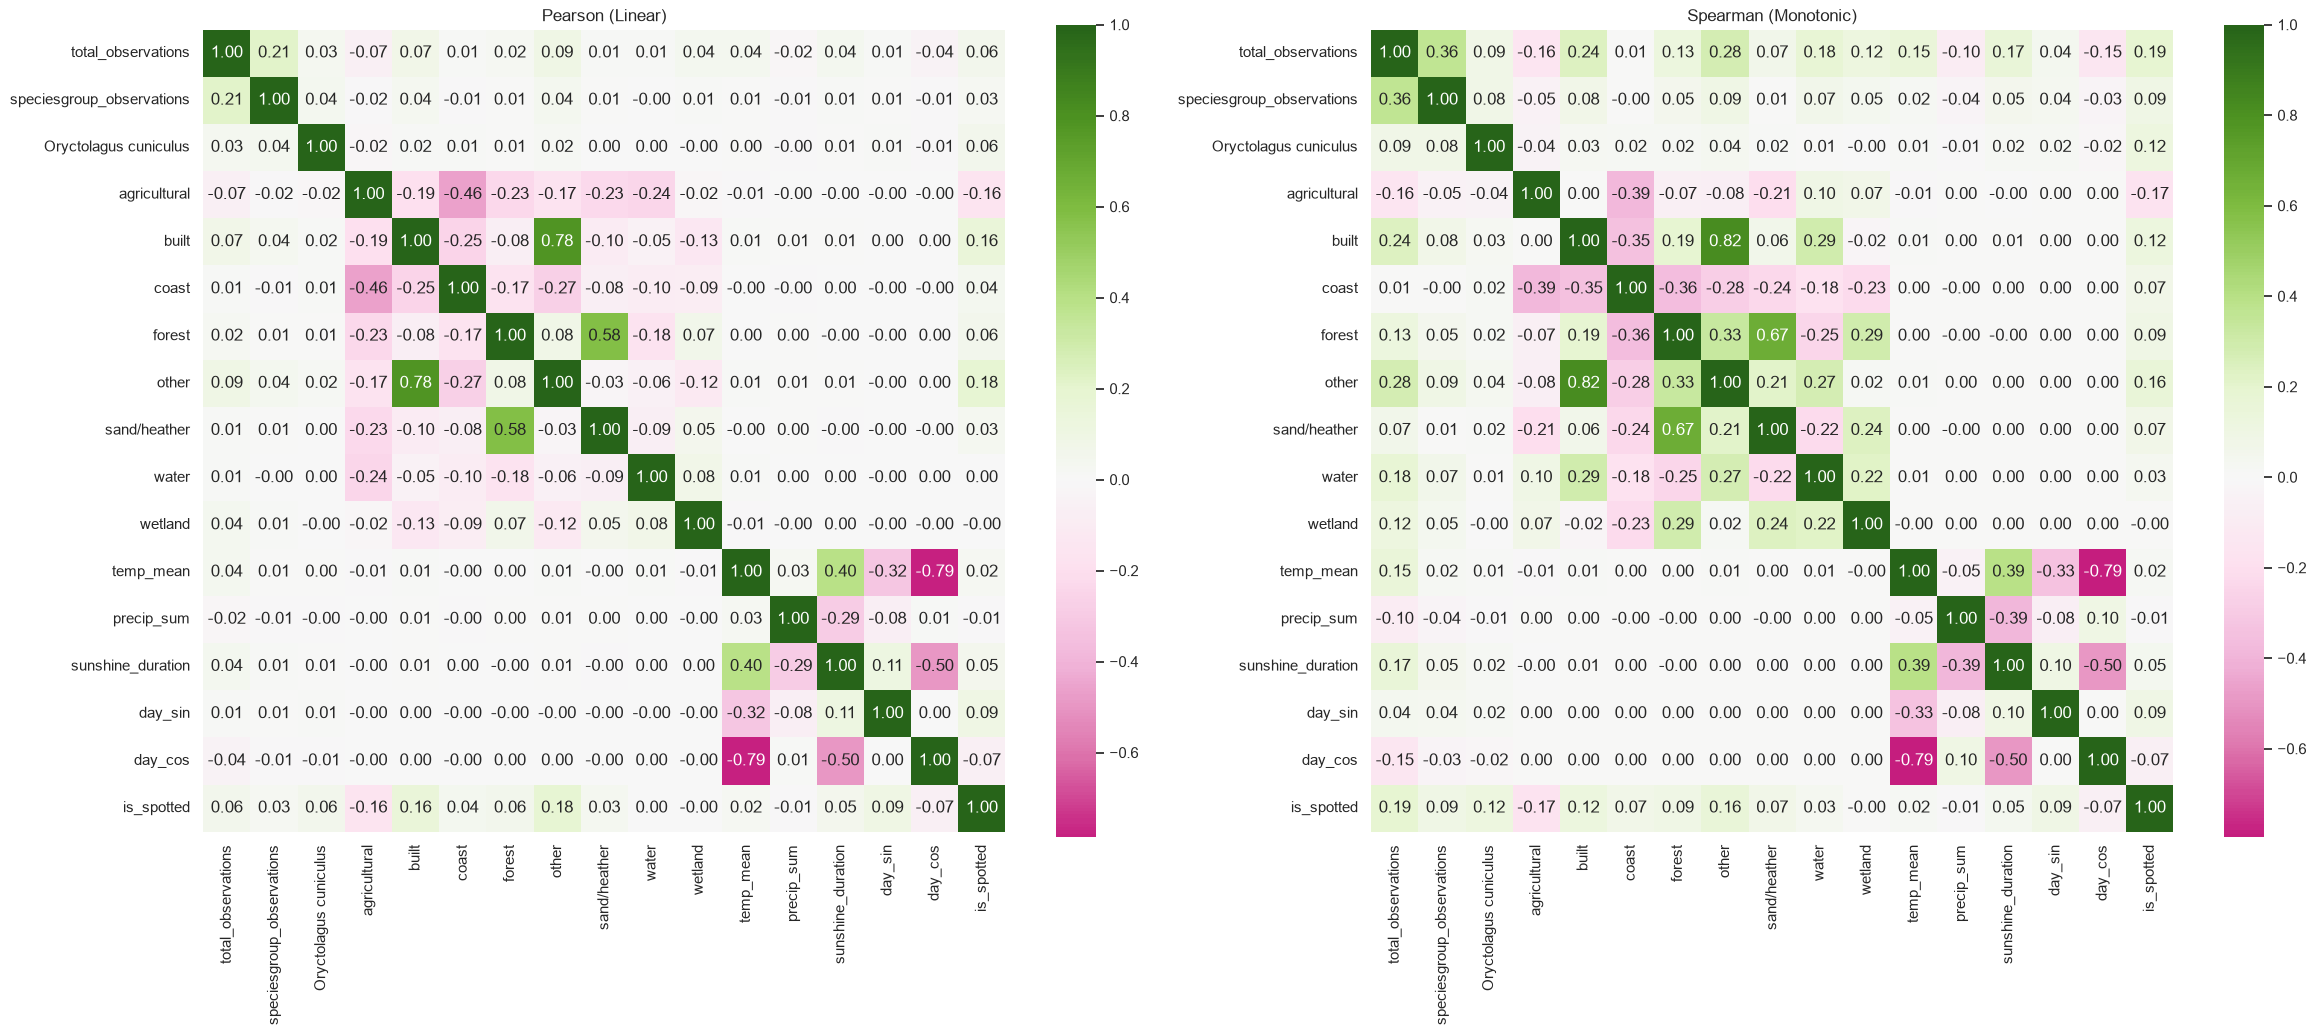

In [16]:
features = [
    "total_observations",
    "speciesgroup_observations",
    "Oryctolagus cuniculus",
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_sin",
    "day_cos",
    "is_spotted"
]

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(df[features].corr(), ax=axes[0], annot=True, fmt=".2f", cmap="PiYG", center=0, square=True)
axes[0].set_title("Pearson (Linear)")

sns.heatmap(df[features].corr(method='spearman'), ax=axes[1], annot=True, fmt=".2f", cmap="PiYG", center=0, square=True)
axes[1].set_title("Spearman (Monotonic)")

plt.tight_layout()
plt.show()

**Findings**

Because all values in the is_spotted row are extremely close to zero, it can be concluded that there is no single linear feature that strongly predicts whether something is spotted. This suggests that the relationship between these features and is_spotted is likely non-linear or complex, and cannot be captured through simple correlation analysis.

## Overall Findings of Data Understanding


# 2.2 Data preparation

**Check duplicates, missing values or typos**

In [17]:
df.isnull().sum()

decimalLatitude                0
decimalLongitude               0
eventDate                      0
total_observations             3
speciesgroup_observations      0
Oryctolagus cuniculus          5
agricultural                  30
built                         30
coast                         30
forest                        30
other                         30
sand/heather                  30
water                         30
wetland                       30
main_habitat                  30
nearest_station                0
station_name                   0
temp_mean                    378
precip_sum                   378
sunshine_duration            547
spotted                        0
is_spotted                     0
day_of_year                    0
day_sin                        0
day_cos                        0
month                          0
dtype: int64

In [18]:
missing = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Percentage (%)": (df.isna().mean() * 100).round(3)
})

missing[missing["Missing values"] > 0]

,Missing values,Percentage (%)
total_observations,3,0.000
Oryctolagus cuniculus,5,0.000
agricultural,30,0.000
built,30,0.000
coast,30,0.000
forest,30,0.000
other,30,0.000
sand/heather,30,0.000
water,30,0.000
wetland,30,0.000


In [19]:
df["total_observations"] = df["total_observations"].fillna(df["total_observations"].median())
df.sort_values(["decimalLatitude", "decimalLongitude"]) \
  .groupby(["decimalLatitude", "decimalLongitude"]) \
  [["temp_mean", "precip_sum", "sunshine_duration"]].ffill()
df = df.dropna()
#check for missing values
df.isnull().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Oryctolagus cuniculus        0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
nearest_station              0
station_name                 0
temp_mean                    0
precip_sum                   0
sunshine_duration            0
spotted                      0
is_spotted                   0
day_of_year                  0
day_sin                      0
day_cos                      0
month                        0
dtype: int64

* *We removed all the zero values because when we took a closer look all the values were extreme and not similar at all to the rest of the data*

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
print(habitat["main_habitat"].unique())

<StringArray>
['agricultural',        'built',        'other',        'water',
       'forest',        'coast', 'sand/heather',      'wetland',
         'dirt']
Length: 9, dtype: str


In [22]:
weather_cols = ['temp_mean', 'precip_sum', 'sunshine_duration']
df[weather_cols].describe()

,temp_mean,precip_sum,sunshine_duration
count,1.255816e+07,1.255816e+07,1.255816e+07
mean,1.087058e+01,2.255325e+00,5.071840e+00
std,6.225568e+00,4.692605e+00,4.236424e+00
min,-1.380000e+01,-1.000000e-01,-1.000000e-01
25%,6.400000e+00,0.000000e+00,1.200000e+00
50%,1.080000e+01,1.000000e-01,4.400000e+00
75%,1.580000e+01,2.500000e+00,8.200000e+00
max,3.120000e+01,1.316000e+02,1.570000e+01


In [23]:
df['temp_mean'] = df['temp_mean'] / 10.0
df['precip_sum'] = df['precip_sum'] / 10.0
df['sunshine_duration'] = df['sunshine_duration'] / 10.0

scaler = RobustScaler()
df[weather_cols] = scaler.fit_transform(df[weather_cols])

print("Weather variables scaled with RobustScaler after unit correction.")
print(df[weather_cols].describe())

Weather variables scaled with RobustScaler after unit correction.
          temp_mean    precip_sum  sunshine_duration
count  1.255816e+07  1.255816e+07       1.255816e+07
mean   7.508566e-03  8.621301e-01       9.597715e-02
std    6.622945e-01  1.877042e+00       6.052034e-01
min   -2.617021e+00 -8.000000e-02      -6.428571e-01
25%   -4.680851e-01 -4.000000e-02      -4.571429e-01
50%    0.000000e+00  0.000000e+00       0.000000e+00
75%    5.319149e-01  9.600000e-01       5.428571e-01
max    2.170213e+00  5.260000e+01       1.614286e+00


This code applies standard scaling to the KNMI weather variables (temp_mean, precip_sum, and sunshine_duration).

It transforms these features so they all have a mean of 0 and a standard deviation of 1. This ensures that variables with different units and ranges (°C, mm, hours) become comparable and no single variable dominates the analysis due to its scale.

It was implemented as a preprocessing step to improve data consistency across environmental features and to prepare the dataset for analysis or modelling where feature magnitude can influence results.

# 3. Modeling
**Model Validation Strategy**

In [24]:
# target
target = "is_spotted"


# features
features = [
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_sin",
    "day_cos"
]


df_model = df[features + [target]].copy()

df_model = df_model.apply(pd.to_numeric, errors="coerce")
df_model = df_model.dropna()

X = df_model[features]
y = df_model[target]

# stratified Kfold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print(f"\nFOLD {fold + 1}")

    print("Train size:", len(X_train))
    print("Test size:", len(X_test))

    print("\nTrain class balance:")
    print(y_train.value_counts(normalize=True))

    print("\nTest class balance:")
    print(y_test.value_counts(normalize=True))

    print("-" * 40)


FOLD 1
Train size: 10046524
Test size: 2511631

Train class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64
----------------------------------------

FOLD 2
Train size: 10046524
Test size: 2511631

Train class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64
----------------------------------------

FOLD 3
Train size: 10046524
Test size: 2511631

Train class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.900299
1    0.099701
Name: proportion, dtype: float64
----------------------------------------

FOLD 4
Train size: 10046524
Test size: 2511631

Train class balance:
is_spotted
0    0.9003
1    0.0997
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.900299
1    0.0

We train test splitted the data into 80% training and 20% testing sets, while maintaining the same proportion of rabbit observations (is_spotted) in both sets.

Model

In [25]:
model1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.6684827508499457
              precision    recall  f1-score   support

           0       0.96      0.66      0.78   2261220
           1       0.19      0.72      0.30    250411

    accuracy                           0.67   2511631
   macro avg       0.57      0.69      0.54   2511631
weighted avg       0.88      0.67      0.73   2511631

Recall: 0.7204395973020354

Confusion Matrix:
[[1498576  762644]
 [  70005  180406]]


In [26]:
model2 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y[y==0]) / len(y[y==1]),
    random_state=42,
    eval_metric='logloss'
)

# Train
model2.fit(X_train, y_train)

# Predict
y_pred = model2.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1740253  520967]
 [  49311  201100]]
              precision    recall  f1-score   support

           0       0.97      0.77      0.86   2261220
           1       0.28      0.80      0.41    250411

    accuracy                           0.77   2511631
   macro avg       0.63      0.79      0.64   2511631
weighted avg       0.90      0.77      0.81   2511631



In [27]:
# 1. Calculate the class imbalance ratio dynamically
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Instantiate the base model
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Define the hyperparameter space to search
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [ratio]
}

# 4. Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 5. Run the hyperparameter search
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# 6. Extract the best model and parameters
best_model = random_search.best_estimator_
print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best CV F1-Score: {random_search.best_score_:.4f}\n")

# 7. Predict and Evaluate using the tuned model
y_pred_tuned = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Starting hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 